In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FSI_Data_2006_2023.csv to FSI_Data_2006_2023.csv


In [ ]:
df = pd.read_csv("/content/FSI_Data_2006_2023.csv")
df.head()

,Country,Year,Rank,Security Apparatus,Factionalized Elites,Group Grievance,Economy,Economic Inequality,Human Flight and Brain Drain,State Legitimacy,Public Services,Human Rights,Demographic Pressures,Refugees and IDPs,External Intervention,Total
0,Sudan,2006,1st,9.8,9.1,9.7,7.5,9.2,9.1,9.5,9.5,9.8,9.6,9.7,9.8,112.3
1,Congo Democratic Republic,2006,2nd,9.8,9.6,9.1,8.1,9.0,8.0,9.0,9.0,9.5,9.5,9.5,10.0,110.1
2,Cote d'Ivoire,2006,3rd,9.8,9.8,9.8,9.0,8.0,8.5,10.0,8.5,9.4,8.8,7.6,10.0,109.2
3,Iraq,2006,4th,9.8,9.7,9.8,8.2,8.7,9.1,8.5,8.3,9.7,8.9,8.3,10.0,109.0
4,Zimbabwe,2006,5th,9.4,8.5,8.5,9.8,9.2,9.0,8.9,9.5,9.5,9.7,8.9,8.0,108.9


In [ ]:
df.shape
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       3170 non-null   object 
 1   Year                          3170 non-null   int64  
 2   Rank                          3170 non-null   object 
 3   Security Apparatus            3170 non-null   float64
 4   Factionalized Elites          3170 non-null   float64
 5   Group Grievance               3170 non-null   float64
 6   Economy                       3170 non-null   float64
 7   Economic Inequality           3170 non-null   float64
 8   Human Flight and Brain Drain  3170 non-null   float64
 9   State Legitimacy              3170 non-null   float64
 10  Public Services               3170 non-null   float64
 11  Human Rights                  3170 non-null   float64
 12  Demographic Pressures         3170 non-null   float64
 13  Ref

,Year,Security Apparatus,Factionalized Elites,Group Grievance,Economy,Economic Inequality,Human Flight and Brain Drain,State Legitimacy,Public Services,Human Rights,Demographic Pressures,Refugees and IDPs,External Intervention,Total
count,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000,3170.000000
mean,2014.601577,5.642271,6.229653,5.947981,5.678675,6.102587,5.549905,6.150442,5.606656,5.756151,5.982271,5.124448,5.665899,69.437035
std,5.145586,2.350244,2.462534,2.108681,1.964632,2.073265,2.062074,2.574501,2.491939,2.434419,2.287515,2.391174,2.397771,23.671346
min,2006.000000,0.300000,0.500000,0.300000,0.400000,0.500000,0.400000,0.200000,0.600000,0.300000,0.300000,0.400000,0.300000,14.500000
25%,2010.000000,4.000000,4.300000,4.325000,4.225000,4.700000,4.100000,4.400000,3.700000,3.800000,4.200000,3.100000,4.000000,52.500000
50%,2015.000000,5.900000,6.900000,6.000000,5.800000,6.500000,6.000000,6.700000,5.800000,6.200000,6.100000,4.900000,6.000000,73.800000
75%,2019.000000,7.300000,8.100000,7.600000,7.100000,7.800000,7.100000,8.100000,7.800000,7.600000,8.000000,7.100000,7.400000,86.300000
max,2023.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,114.900000


In [ ]:
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.replace(" ", "_")
df.head()

,Country,Year,Rank,Security_Apparatus,Factionalized_Elites,Group_Grievance,Economy,Economic_Inequality,Human_Flight_and_Brain_Drain,State_Legitimacy,Public_Services,Human_Rights,Demographic_Pressures,Refugees_and_IDPs,External_Intervention,Total
0,Sudan,2006,1st,9.8,9.1,9.7,7.5,9.2,9.1,9.5,9.5,9.8,9.6,9.7,9.8,112.3
1,Congo Democratic Republic,2006,2nd,9.8,9.6,9.1,8.1,9.0,8.0,9.0,9.0,9.5,9.5,9.5,10.0,110.1
2,Cote d'Ivoire,2006,3rd,9.8,9.8,9.8,9.0,8.0,8.5,10.0,8.5,9.4,8.8,7.6,10.0,109.2
3,Iraq,2006,4th,9.8,9.7,9.8,8.2,8.7,9.1,8.5,8.3,9.7,8.9,8.3,10.0,109.0
4,Zimbabwe,2006,5th,9.4,8.5,8.5,9.8,9.2,9.0,8.9,9.5,9.5,9.7,8.9,8.0,108.9


In [ ]:
def risk_level(score):
    if score >= 90:
        return "High Risk"
    elif score >= 60:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df["Total"].apply(risk_level)

df["Score_Change"] = df.groupby("Country")["Total"].diff()

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       3170 non-null   object 
 1   Year                          3170 non-null   int64  
 2   Rank                          3170 non-null   object 
 3   Security_Apparatus            3170 non-null   float64
 4   Factionalized_Elites          3170 non-null   float64
 5   Group_Grievance               3170 non-null   float64
 6   Economy                       3170 non-null   float64
 7   Economic_Inequality           3170 non-null   float64
 8   Human_Flight_and_Brain_Drain  3170 non-null   float64
 9   State_Legitimacy              3170 non-null   float64
 10  Public_Services               3170 non-null   float64
 11  Human_Rights                  3170 non-null   float64
 12  Demographic_Pressures         3170 non-null   float64
 13  Ref

In [ ]:
total_countries = df["Country"].nunique()

print("Total Countries:", total_countries)

Total Countries: 187


In [ ]:
total_records = df.shape[0]

print("Total Records:", total_records)

Total Records: 3170


In [ ]:
average_score = df["Total"].mean()

print("Average FSI Score:", round(average_score, 2))

Average FSI Score: 69.44


In [ ]:
high_risk_count = df[df["Risk_Level"] == "High Risk"]["Country"].nunique()

print("High Risk Countries:", high_risk_count)

High Risk Countries: 52


In [ ]:
medium_risk_count = df[df["Risk_Level"] == "Medium Risk"]["Country"].nunique()

print("Medium Risk Countries:", medium_risk_count)

Medium Risk Countries: 122


In [ ]:
low_risk_count = df[df["Risk_Level"] == "Low Risk"]["Country"].nunique()

print("Low Risk Countries:", low_risk_count)

Low Risk Countries: 70


In [ ]:
highest_risk = df.loc[df["Total"].idxmax(), ["Country", "Year", "Total"]]

print(highest_risk)

Country    Somalia
Year          2012
Total        114.9
Name: 1031, dtype: object


In [ ]:
lowest_risk = df.loc[df["Total"].idxmin(), ["Country", "Year", "Total"]]

print(lowest_risk)

Country    Norway
Year         2023
Total        14.5
Name: 3169, dtype: object


In [ ]:
yearly_average = df.groupby("Year")["Total"].mean()

yearly_average

,Total
Year,
2006,70.790411
2007,70.558757
2008,70.858192
2009,72.066102
2010,71.874011
2011,71.094915
2012,70.883708
2013,70.487640
2014,70.581461


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Countries",
        "Total Records",
        "Average FSI Score",
        "High Risk Countries",
        "Medium Risk Countries",
        "Low Risk Countries"
    ],
    "Value": [
        total_countries,
        total_records,
        round(average_score, 2),
        high_risk_count,
        medium_risk_count,
        low_risk_count
    ]
})

kpi_summary

,KPI,Value
0,Total Countries,187.00
1,Total Records,3170.00
2,Average FSI Score,69.44
3,High Risk Countries,52.00
4,Medium Risk Countries,122.00
5,Low Risk Countries,70.00


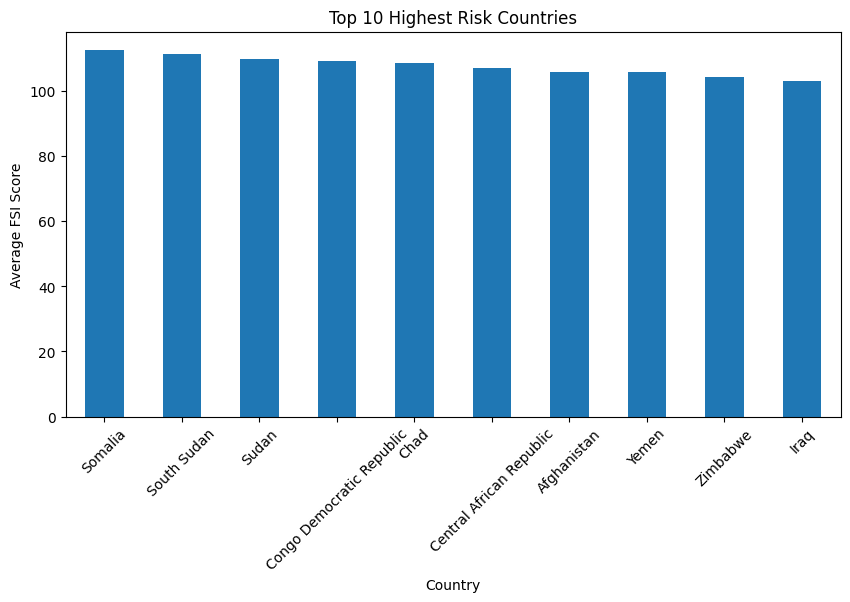

In [ ]:
top_risk = df.groupby("Country")["Total"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_risk.plot(kind="bar")

plt.title("Top 10 Highest Risk Countries")
plt.xlabel("Country")
plt.ylabel("Average FSI Score")
plt.xticks(rotation=45)
plt.show()

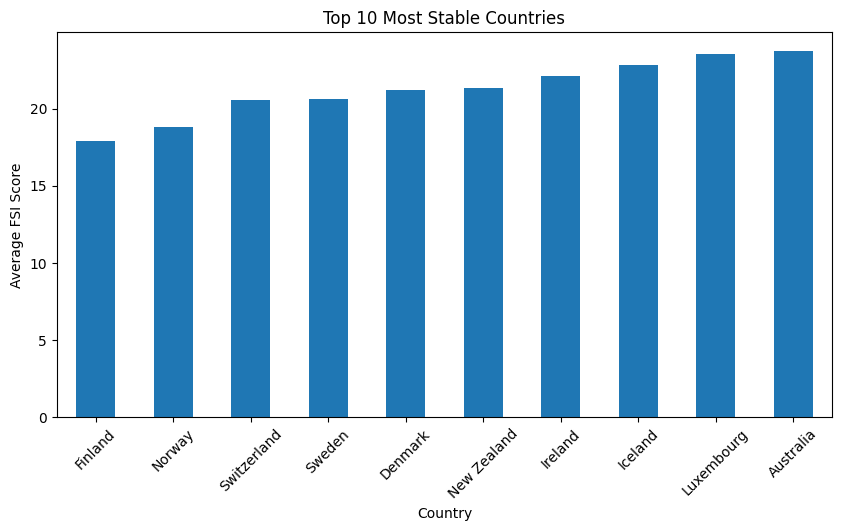

In [ ]:
stable_countries = df.groupby("Country")["Total"].mean().sort_values().head(10)

plt.figure(figsize=(10,5))
stable_countries.plot(kind="bar")

plt.title("Top 10 Most Stable Countries")
plt.xlabel("Country")
plt.ylabel("Average FSI Score")
plt.xticks(rotation=45)
plt.show()

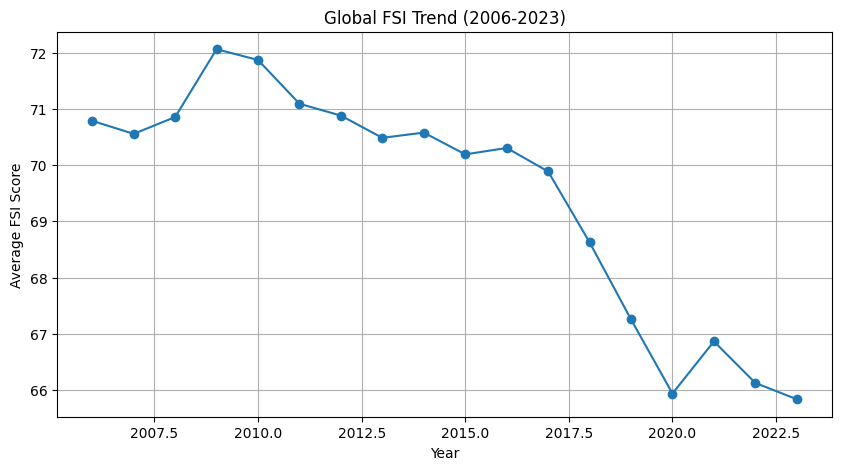

In [ ]:
yearly_trend = df.groupby("Year")["Total"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_trend.index, yearly_trend.values, marker="o")

plt.title("Global FSI Trend (2006-2023)")
plt.xlabel("Year")
plt.ylabel("Average FSI Score")
plt.grid(True)

plt.show()

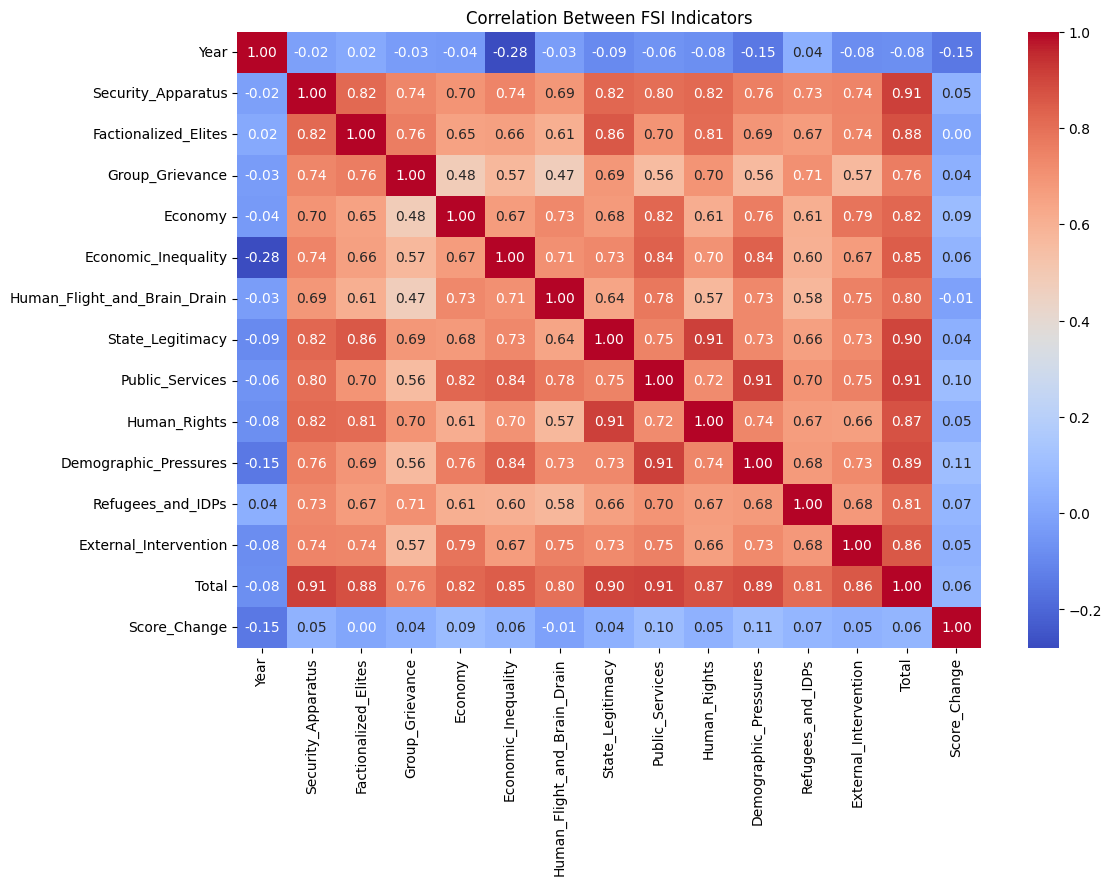

In [ ]:
numeric_data = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between FSI Indicators")
plt.show()

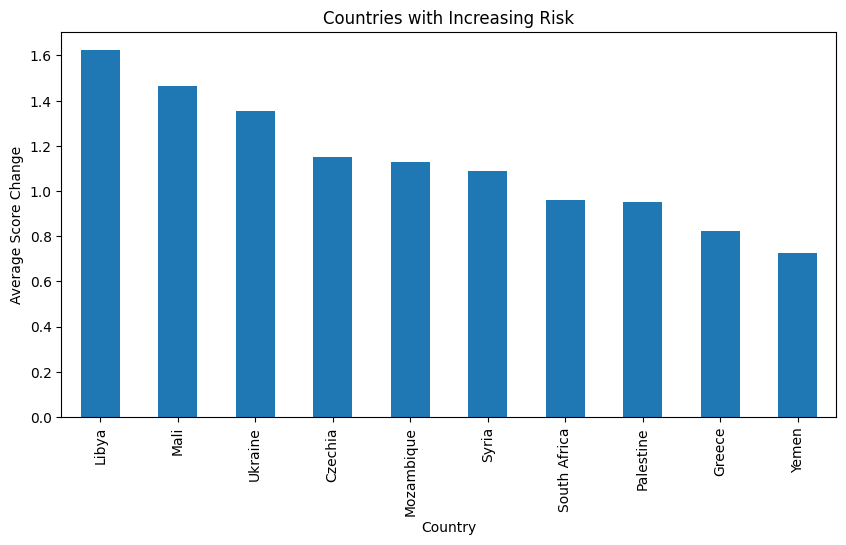

In [ ]:
change = df.groupby("Country")["Score_Change"].mean()

highest_change = change.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
highest_change.plot(kind="bar")

plt.title("Countries with Increasing Risk")
plt.xlabel("Country")
plt.ylabel("Average Score Change")

plt.show()

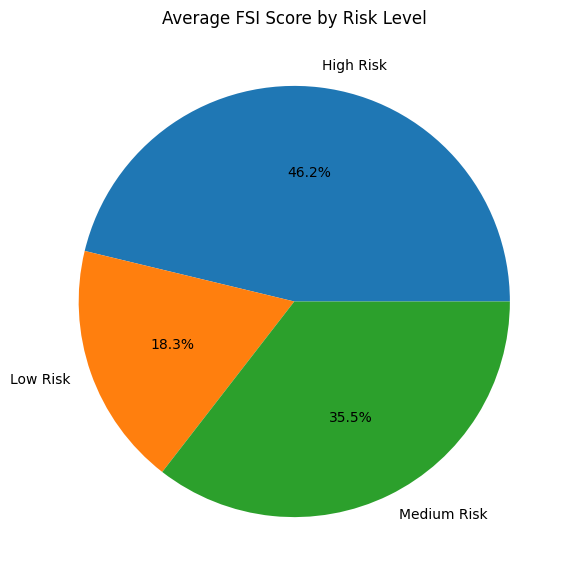

In [ ]:
risk_avg = df.groupby("Risk_Level")["Total"].mean()

risk_avg.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Average FSI Score by Risk Level")
plt.ylabel("")
plt.show()

In [ ]:
print("===== FSI Global Dashboard =====")

print("Total Countries:", total_countries)
print("Total Records:", total_records)
print("Average FSI Score:", round(average_score, 2))
print("High Risk Countries:", high_risk_count)
print("Medium Risk Countries:", medium_risk_count)
print("Low Risk Countries:", low_risk_count)

===== FSI Global Dashboard =====
Total Countries: 187
Total Records: 3170
Average FSI Score: 69.44
High Risk Countries: 52
Medium Risk Countries: 122
Low Risk Countries: 70


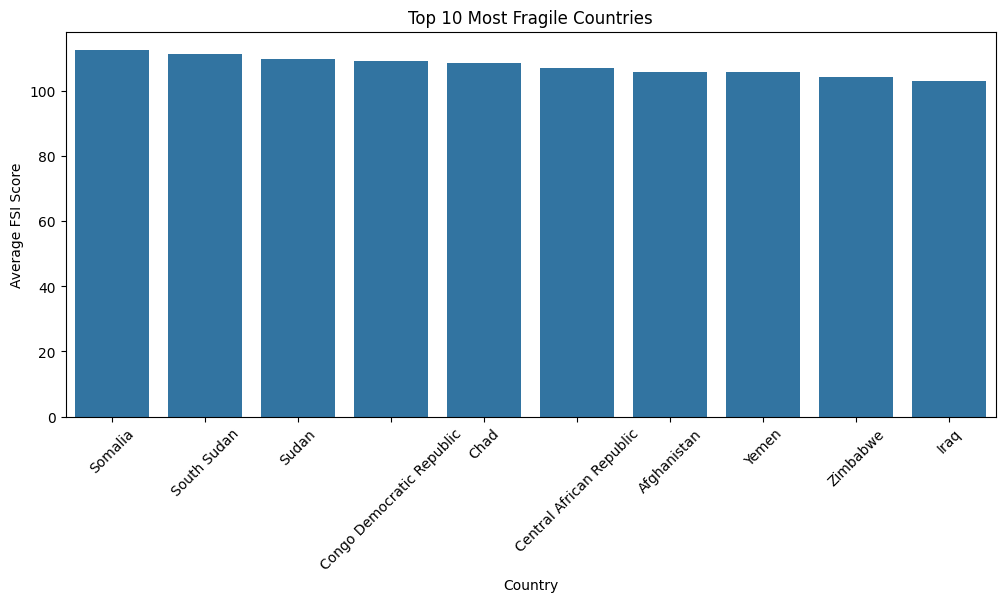

In [ ]:
top10 = df.groupby("Country")["Total"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 Most Fragile Countries")
plt.xlabel("Country")
plt.ylabel("Average FSI Score")
plt.xticks(rotation=45)

plt.show()

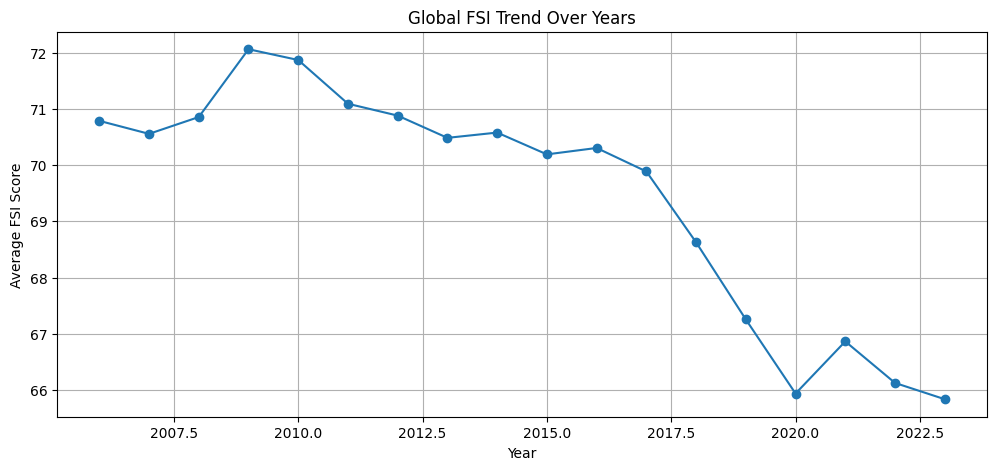

In [ ]:
year_trend = df.groupby("Year")["Total"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    year_trend.index,
    year_trend.values,
    marker="o"
)

plt.title("Global FSI Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average FSI Score")
plt.grid(True)

plt.show()

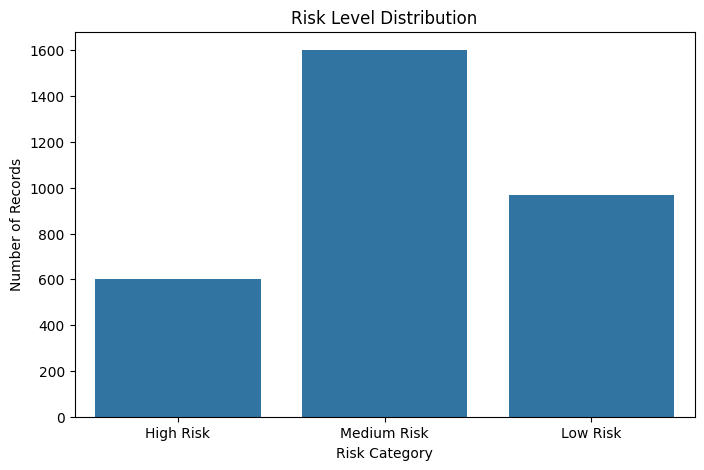

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Risk_Level"
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")

plt.show()

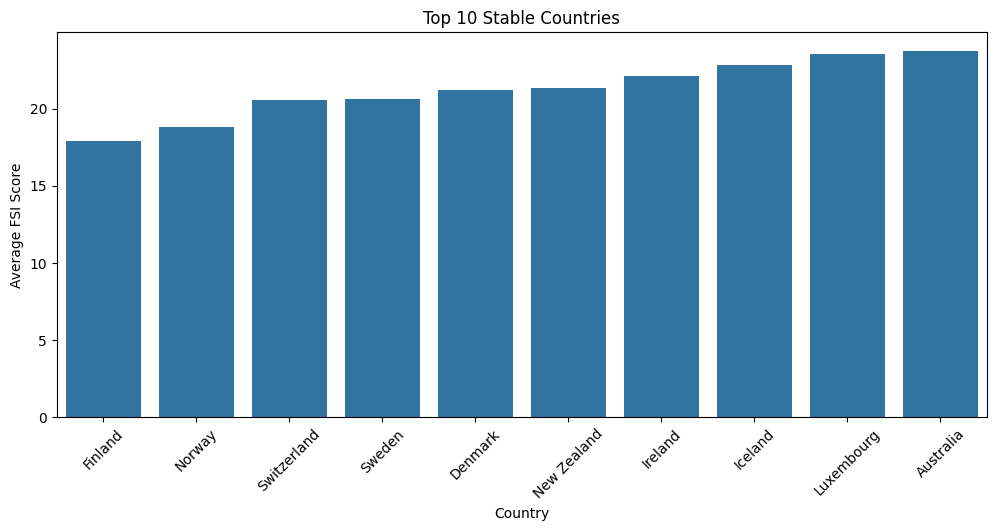

In [ ]:
stable = df.groupby("Country")["Total"].mean().sort_values().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=stable.index,
    y=stable.values
)

plt.title("Top 10 Stable Countries")
plt.xlabel("Country")
plt.ylabel("Average FSI Score")

plt.xticks(rotation=45)

plt.show()

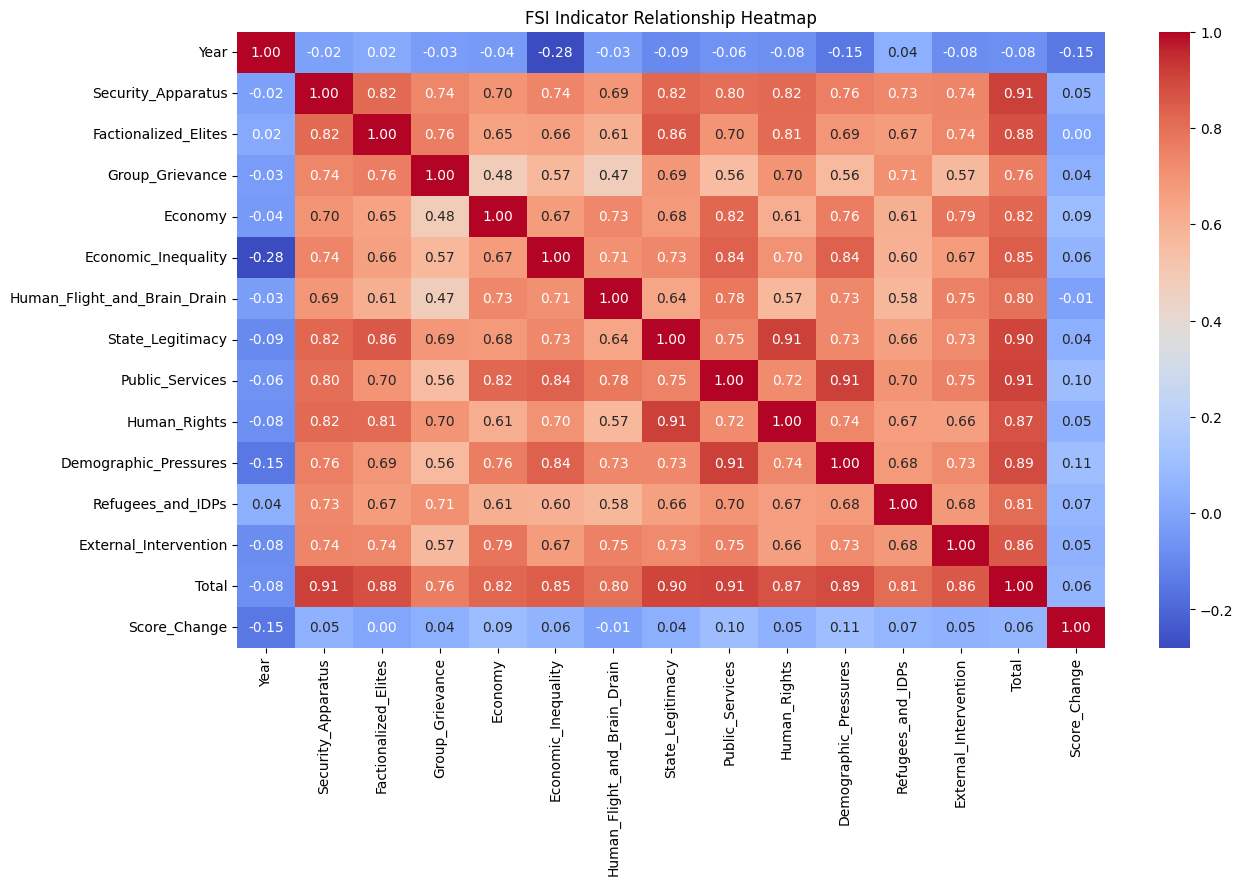

In [ ]:
numeric_columns = df.select_dtypes(include="number")

plt.figure(figsize=(14,8))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("FSI Indicator Relationship Heatmap")

plt.show()